In [1]:
import pandas as pd
import numpy as np
import os
import re
from tqdm import tqdm

In [2]:
import spacy
from collections import Counter
import string

In [3]:
import textblob
from textblob import TextBlob

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from concurrent.futures import ProcessPoolExecutor

In [14]:
#pd.set_option('display.max_colwidth', None)  # 允许显示完整内容

In [6]:
data= pd.read_excel("C:/Users/WQM/Desktop/本科英语毕业论文/数据集/FNSPID/output3_cleaned.xlsx")
data= pd.DataFrame(data)

In [7]:
# 加载 spaCy 语言模型，禁用了 依存解析（parser） 和 命名实体识别（NER） 这两个组件
nlp = spacy.load("en_core_web_lg", disable=["parser", "ner"])  

In [12]:
'''
def clean_text(doc):
    return " ".join([token.text.lower() for token in doc if token.text not in string.punctuation])

# 使用 tqdm 进度条 + nlp.pipe() 处理 Article_title
print("Processing Article_title...")
data["Article_title"] = [
    clean_text(doc) for doc in tqdm(nlp.pipe(data["Article_title"], batch_size=1000), total=len(data))
]

# 处理 Article 列
print("Processing Article...")
data["Article"] = [
    clean_text(doc) for doc in tqdm(nlp.pipe(data["Article"], batch_size=1500), total=len(data))
]
'''

In [ ]:
# 描述性分析

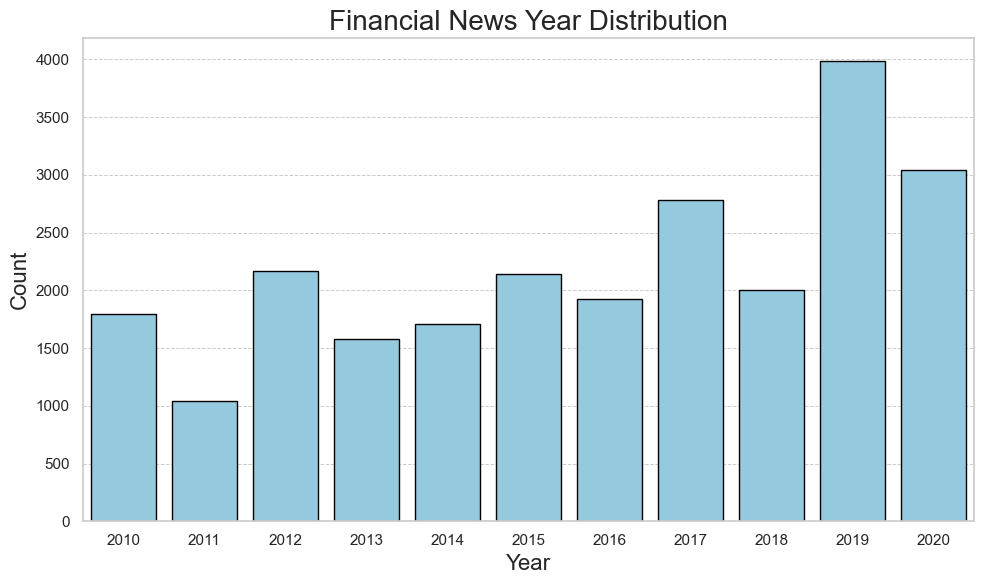

In [41]:
# 设置 Seaborn 样式为带有虚线网格的背景
sns.set(style="whitegrid", palette="pastel", rc={"grid.linestyle": "--"})

# 计算每年的计数，并按年份排序
yearly_counts = data['Year'].value_counts().sort_index()

# 创建图表对象，设置图表尺寸
plt.figure(figsize=(10, 6))

# 绘制柱状图，并设置颜色和边框
ax = sns.barplot(x=yearly_counts.index, y=yearly_counts.values, color='skyblue', edgecolor='black')

# 添加标题和轴标签
plt.title('Financial News Year Distribution', fontsize=20)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Count', fontsize=16)

# 添加虚线网格线
plt.grid(axis='y', linestyle='--', linewidth=0.7)


# 保存图表为图片
plt.savefig('Financial News Year Distribution.jpg', format='jpg', dpi=300, bbox_inches='tight')

# 自动布局调整，避免标签重叠
plt.tight_layout()

# 显示图表
plt.show()

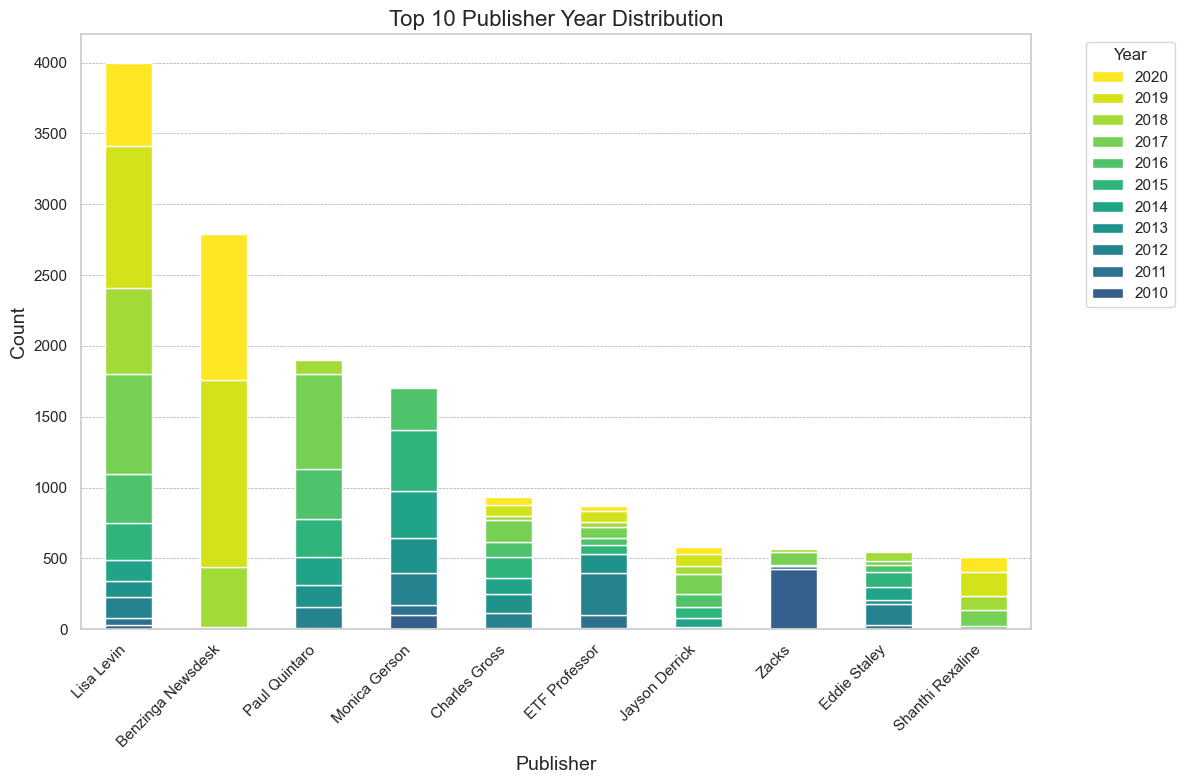

In [60]:
# 计算每个 Publisher 在每一年出现的次数
publisher_year_counts = data.groupby(['Publisher', 'Year']).size().unstack(fill_value=0)

# 只保留出现次数最多的前 10 个 Publisher
top_publishers = data['Publisher'].value_counts().head(10).index
publisher_year_counts = publisher_year_counts.loc[top_publishers]

# 获取年份列表
years = publisher_year_counts.columns

# 为不同年份创建渐变色
colors = plt.cm.viridis(np.linspace(0.3, 1, len(years)))

# 绘制堆叠柱状图
ax = publisher_year_counts.plot(kind='bar', stacked=True, figsize=(12, 8), color=colors)

# 添加标题和标签
ax.set_title('Top 10 Publisher Year Distribution', fontsize=16)
ax.set_xlabel('Publisher', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# 关闭纵向网格，只保留横向虚线网格
ax.grid(axis='x', visible=False)  # 关闭纵向网格
ax.grid(axis='y', linestyle='--', linewidth=0.5, color='gray', alpha=0.7)  # 添加横向虚线

# 调整图例顺序
handles, labels = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels, handles))  # 将年份与句柄映射
sorted_labels = sorted(legend_dict.keys(), reverse=True)  # 按年份降序排序
sorted_handles = [legend_dict[label] for label in sorted_labels]

# 设置图例在右侧
ax.legend(sorted_handles, sorted_labels, title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

# 调整 X 轴刻度标签显示
plt.xticks(rotation=45, ha='right')

# 自动布局调整，避免标签重叠
plt.tight_layout()

# 保存图表为图片，并确保完整显示
plt.savefig(
    'Top 10 Publisher Year Distribution.jpg',  # 使用 PNG 格式保存
    format='jpg',       # 指定图片格式
    dpi=300,            # 提升分辨率
    bbox_inches='tight' # 自动调整边距，避免元素被裁剪
)

# 显示图表
plt.show()

In [51]:
# 计算前 10 名 Publisher 的新闻总数
top_10_count = data['Publisher'].value_counts().head(10).sum()

# 计算所有新闻的总数
total_count = len(data)

# 计算占比
percentage = (top_10_count / total_count) * 100

print(percentage)

59.617454665893845


In [ ]:
# Finbert机器学习模型情感分析

In [7]:
import transformers

In [8]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

In [9]:
# 加载FinBERT的预训练模型和分词器
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")

In [10]:
# 进行情感分析
def get_sentiment(text):
    # 将文本转化为模型输入
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    
    # 获取模型输出
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()

    # 0 = negative, 1 = neutral, 2 = positive
    return predicted_class

In [11]:
# 显示进度条
tqdm.pandas()

# 为每篇文章计算情感，并添加进度条
data['FB_title_polarity'] = data['Article_title'].progress_apply(get_sentiment)

# 将情感值映射为 +1（正面）、-1（负面）、0（中性）
data['FB_title_polarity'] = data['FB_title_polarity'].map({0: -1, 1: 0, 2: 1})

100%|████████████████████████████████████████████████████████████████████████████| 24154/24154 [36:00<00:00, 11.18it/s]


In [13]:
# 按年份分组，计算每年情感极性得分的平均值
yearly_sentiment = data.groupby('Year')['FB_title_polarity'].mean()
print(yearly_sentiment)

Year
2010    0.584590
2011    0.578846
2012    0.468851
2013    0.360583
2014    0.311437
2015    0.347664
2016    0.353430
2017    0.336210
2018    0.358603
2019    0.279759
2020    0.261427
Name: FB_title_polarity, dtype: float64


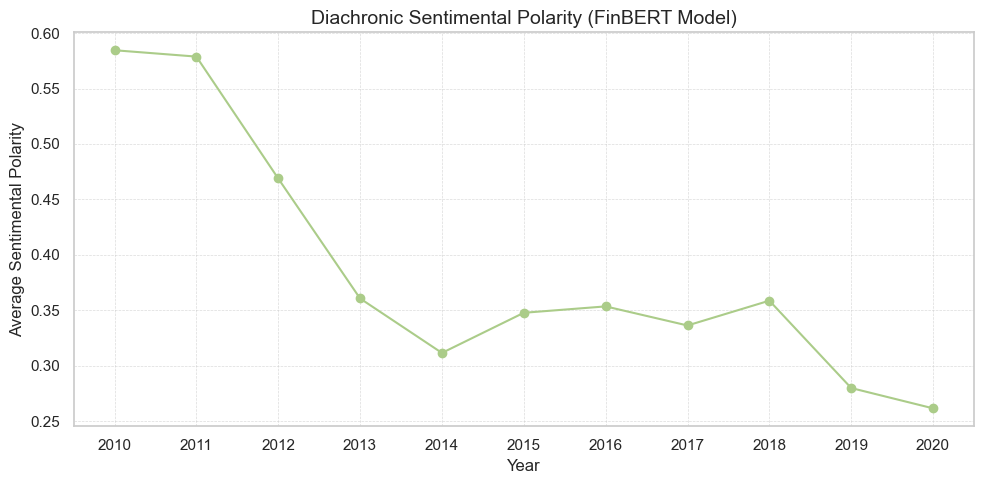

In [84]:
plt.figure(figsize=(10, 5))

# 绘制折线图
plt.plot(yearly_sentiment.index, yearly_sentiment.values, marker="o", linestyle="-", color="#ABCC89")

# 轴标签和标题
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Sentimental Polarity", fontsize=12)
plt.title("Diachronic Sentimental Polarity (FinBERT Model)", fontsize=14)

# 设置 y 轴从 0 开始
# plt.ylim(0, None)

# 细虚线网格
plt.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# 设置 x 轴刻度，确保每年都有
plt.xticks(yearly_sentiment.index, yearly_sentiment.index)

# 调整布局
plt.tight_layout()

# 保存图像
plt.savefig("Diachronic Sentimental Polarity (FinBERT Model).jpg", format="jpg", dpi=300)

# 显示图像
plt.show()

In [14]:
# 根据情感得分分类（大于0为正，等于0为中性，小于0为负）
data["FB_title_label"] = data["FB_title_polarity"].apply(lambda x: "positive" if x > 0 else ("negative" if x < 0 else "neutral"))

# 计算每年不同情感的比例
sentiment_counts = data.groupby(["Year", "FB_title_label"]).size().unstack().fillna(0)
sentiment_ratios = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0)

In [15]:
sentiment_ratios

FB_title_label,negative,neutral,positive
Year,,,
2010,0.156337,0.102736,0.740927
2011,0.143269,0.134615,0.722115
2012,0.191970,0.147208,0.660821
2013,0.220532,0.198352,0.581115
2014,0.235777,0.217009,0.547214
2015,0.226168,0.200000,0.573832
2016,0.202183,0.242204,0.555613
2017,0.207839,0.248112,0.544049
2018,0.192519,0.256359,0.551122


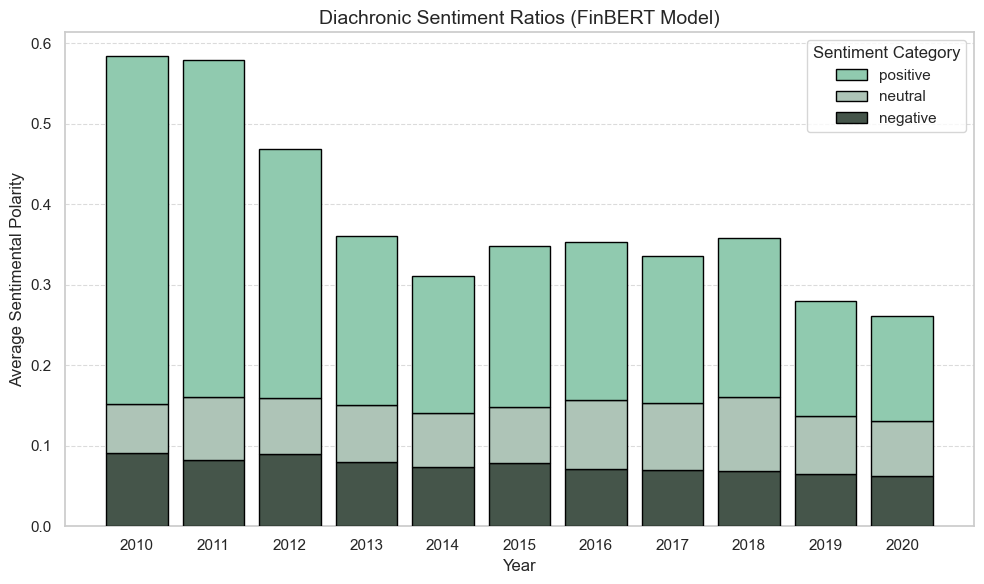

In [85]:
# 设定颜色
colors = {"positive": "#90caaf", "neutral": "#aec4b7", "negative": "#45554A"}

# 维持原始情感堆叠顺序
sentiment_order = ["negative", "neutral", "positive"]

# 绘制堆叠柱状图
fig, ax = plt.subplots(figsize=(10, 6))

bottoms = np.zeros(len(yearly_sentiment))  # 初始化底部为 0
bars = {}  # 用于存储各个情感类别的柱子，以便调整图例

for sentiment in sentiment_order:
    if sentiment in sentiment_ratios.columns:
        bars[sentiment] = ax.bar(
            yearly_sentiment.index,  
            yearly_sentiment.values * sentiment_ratios[sentiment],  
            label=sentiment,
            bottom=bottoms,  
            color=colors[sentiment],
            edgecolor="black",
            zorder=3,  # 确保柱形图位于网格线之上
        )
        bottoms += yearly_sentiment.values * sentiment_ratios[sentiment]  

# 添加标题和标签
ax.set_title("Diachronic Sentiment Ratios (FinBERT Model)", fontsize=14)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Average Sentimental Polarity", fontsize=12)

# 让 X 轴仅显示年份
plt.xticks(yearly_sentiment.index)


# 设置网格，仅作用于 y 轴，且在柱状图之下
ax.grid(axis='x', visible=False)  # 关闭纵向网格
ax.grid(axis='y',linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)

# 重新排序图例
handles, labels = ax.get_legend_handles_labels()
new_order = ["positive", "neutral", "negative"]  # 调整图例显示顺序
sorted_handles = [bars[sentiment] for sentiment in new_order]  # 按新顺序获取柱形图对象
ax.legend(sorted_handles, new_order, title="Sentiment Category")

# 调整布局
plt.tight_layout()

# 保存图像
plt.savefig("Diachronic Sentiment Ratios (FinBERT Model).jpg", format="jpg", dpi=300)

# 显示图表
plt.show()

In [ ]:
# 标题Textblob情感极性

In [65]:
# 计算每个标题的情感极性
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity  # 计算情感极性

data["TB_Title_Polarity"] = data["Article_title"].apply(get_sentiment)  # 计算每个标题的情感极性

# 按年份计算平均情感极性
title_sentiment = data.groupby("Year")["TB_Title_Polarity"].mean()

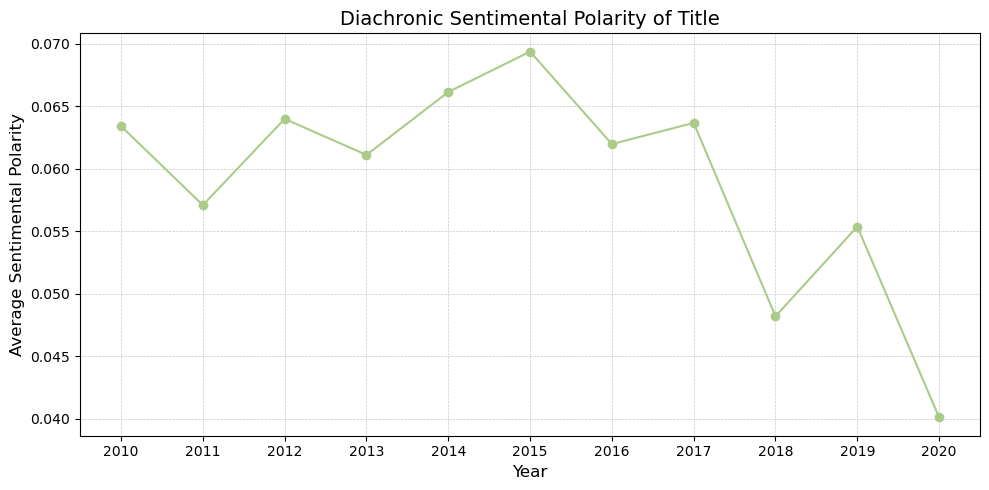

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# 绘制折线图
plt.plot(title_sentiment.index, title_sentiment.values, marker="o", linestyle="-", color="#ABCC89")

# 轴标签和标题
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Sentimental Polarity", fontsize=12)
plt.title("Diachronic Sentimental Polarity of Title", fontsize=14)

# 设置 y 轴从 0 开始
# plt.ylim(0, None)

# 细虚线网格
plt.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# 设置 x 轴刻度，确保每年都有
plt.xticks(title_sentiment.index, title_sentiment.index)

# 调整布局
plt.tight_layout()

# 显示图像
plt.show()

In [ ]:
# 文章Textblob情感极性

In [24]:
# 计算每篇文章的情感极性
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity  # 计算情感极性

data["article_sentiment"] = data["Article"].apply(get_sentiment)  # 计算每个标题的情感极性

# 按年份计算平均情感极性
article_sentiment = data.groupby("Year")["article_sentiment"].mean()

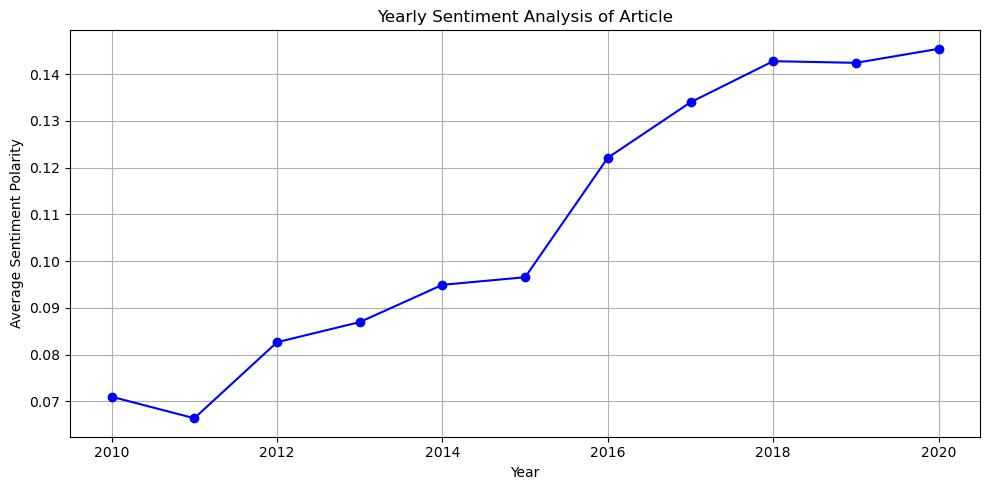

In [25]:
# 可视化
plt.figure(figsize=(10, 5))
plt.plot(article_sentiment.index, article_sentiment.values, marker="o", linestyle="-", color="b")
plt.xlabel("Year")
plt.ylabel("Average Sentiment Polarity")
plt.title("Diachronic Sentiment Analysis of Article")
plt.tight_layout()
plt.grid()
plt.show()

In [ ]:
# 标题Textblob情感极性比例

In [80]:
'''
# 计算情感极性
def get_sentiment(text):
    doc = nlp(text)
    return doc._.polarity if hasattr(doc._, "polarity") else 0  # 确保 Spacy 有情感分析插件
'''

'\n# 计算情感极性\ndef get_sentiment(text):\n    doc = nlp(text)\n    return doc._.polarity if hasattr(doc._, "polarity") else 0  # 确保 Spacy 有情感分析插件\n'

In [84]:
# 按年份计算平均情感极性
title_sentiment = data.groupby("Year")["TB_Title_Polarity"].mean()

# 根据情感得分分类（大于0为正，等于0为中性，小于0为负）
data["sentiment_label"] = data["TB_Title_Polarity"].apply(lambda x: "positive" if x > 0 else ("negative" if x < 0 else "neutral"))

# 计算每年不同情感的比例
sentiment_counts = data.groupby(["Year", "sentiment_label"]).size().unstack().fillna(0)
sentiment_ratios = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0)

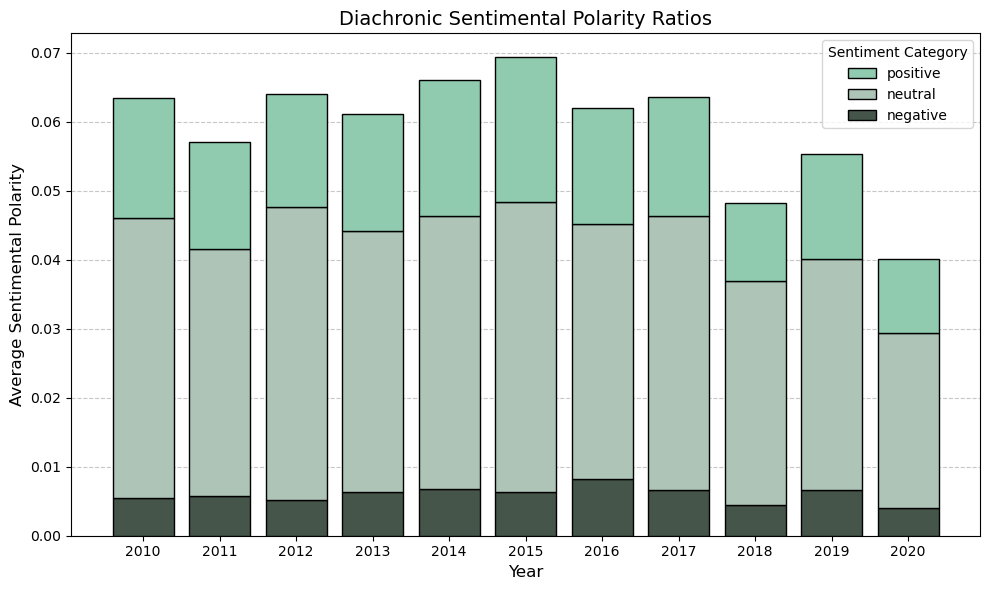

In [98]:
# 设定颜色
colors = {"positive": "#90caaf", "neutral": "#aec4b7", "negative": "#45554A"}

# 维持原始情感堆叠顺序
sentiment_order = ["negative", "neutral", "positive"]

# 绘制柱状图
fig, ax = plt.subplots(figsize=(10, 6))

bottoms = np.zeros(len(title_sentiment))  # 初始化底部为 0
bars = {}  # 用于存储各个情感类别的柱子，以便调整图例

for sentiment in sentiment_order:
    if sentiment in sentiment_ratios.columns:
        bars[sentiment] = ax.bar(
            title_sentiment.index,  
            title_sentiment.values * sentiment_ratios[sentiment],  
            label=sentiment,
            bottom=bottoms,  
            color=colors[sentiment],
            edgecolor="black",
            zorder=3,  # 确保柱形图位于网格线之上
        )
        bottoms += title_sentiment.values * sentiment_ratios[sentiment]  

# 添加标题和标签
ax.set_title("Diachronic Sentimental Polarity Ratios", fontsize=14)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Average Sentimental Polarity", fontsize=12)

# 让 X 轴仅显示年份
plt.xticks(title_sentiment.index)

# 设置网格，仅作用于 y 轴，且在柱状图之下
ax.grid(axis="y", linestyle="--", alpha=0.7, zorder=0)

# 重新排序图例
handles, labels = ax.get_legend_handles_labels()
new_order = ["positive", "neutral", "negative"]  # 调整图例显示顺序
sorted_handles = [bars[sentiment] for sentiment in new_order]  # 按新顺序获取柱形图对象
ax.legend(sorted_handles, new_order, title="Sentiment Category")

# 调整布局
plt.tight_layout()

# 显示图表
plt.show()

In [26]:
#基于Loughran-McDonald词典的情感分

In [27]:
dictionary= pd.read_excel("C:/Users/WQM/Desktop/本科英语毕业论文/数据集/FNSPID/Dictionary/Loughran-McDonald_MasterDictionary_1993-2023.xlsx")
dictionary= pd.DataFrame(dictionary)

In [28]:
dictionary_sim= dictionary.loc[:,['Word', 'Positive', 'Negative', 'Uncertainty']]

In [29]:
# 初始化类别词典
word_dict = {
    'positive': [],
    'negative': [],
    'neutral': []
}

In [30]:
# 遍历DataFrame，分类存入字典
for _, row in dictionary_sim.iterrows():
    if row['Positive'] != 0:
        word_dict['positive'].append(row['Word'])
    if row['Negative'] != 0:
        word_dict['negative'].append(row['Word'])
    if row['Uncertainty'] != 0:
        word_dict['neutral'].append(row['Word'])

In [31]:
# 将字典中的每个词（包括布尔值）转换为小写
for key in word_dict:
    word_dict[key] = [str(word).lower() for word in word_dict[key]]  # 转换为字符串并小写

In [32]:
# 计算词频
def count_words(text, word_list):
    return sum(text.lower().split().count(word) for word in word_list)

In [33]:
data['LM_Title_Positive'] = data['Article_title'].apply(lambda x: count_words(x, word_dict['positive']))
data['LM_Title_Negative'] = data['Article_title'].apply(lambda x: count_words(x, word_dict['negative']))
data['Title_Total_Words'] = data['Article_title'].apply(lambda x: len(x.split()))  # 计算文章词数

# 计算情感极性和主观性
data['LM_Title_Polarity'] = (data['LM_Title_Positive'] - data['LM_Title_Negative']) / (data['LM_Title_Positive'] + data['LM_Title_Negative']).replace(0, 1)  # 避免除0
data['LM_Title_Subjectivity'] = (data['LM_Title_Positive'] + data['LM_Title_Negative']) / data['Title_Total_Words']

In [41]:
# 按年计算平均值
yearly_stats = data.groupby('Year')[['LM_Title_Polarity', 'LM_Title_Subjectivity']].mean().reset_index()

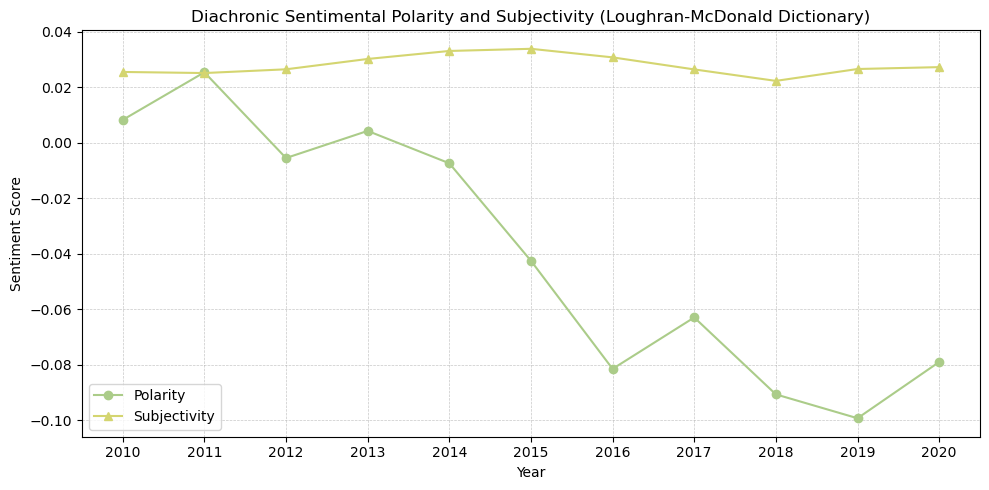

In [43]:
# 画图
plt.figure(figsize=(10, 5))
plt.plot(yearly_stats['Year'], yearly_stats['LM_Title_Polarity'], marker='o', linestyle='-', label='Polarity', color='#ABCC89')
plt.plot(yearly_stats['Year'], yearly_stats['LM_Title_Subjectivity'], marker='^', linestyle='-', label='Subjectivity', color='#D4D570')

# 设置 x 轴刻度，确保每个年份都显示
plt.xticks(yearly_stats['Year'])

# 细虚线网格
plt.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.xlabel('Year')
plt.ylabel('Sentiment Score')
plt.title('Diachronic Sentimental Polarity and Subjectivity (Loughran-McDonald Dictionary)')
plt.legend()

plt.tight_layout()

# 保存图像
plt.savefig("Diachronic Sentimental Polarity and Subjectivity (Loughran-McDonald Dictionary).jpg", format="jpg", dpi=300)
plt.show()

In [18]:
# 计算词频
def count_words(text, word_list):
    return sum(text.lower().split().count(word) for word in word_list)

In [19]:
# 使用 tqdm 包装 DataFrame 的 apply 方法
tqdm.pandas()

# 计算正面词汇数
data['Article_Positive_Word'] = data['Article'].progress_apply(lambda x: count_words(x, word_dict['positive']))

# 计算负面词汇数
data['Article_Negative_Word'] = data['Article'].progress_apply(lambda x: count_words(x, word_dict['negative']))

# 计算文章总词数
data['Article_Total_Words'] = data['Article'].progress_apply(lambda x: len(x.split()))  # 计算文章词数

# 计算情感极性和主观性
data['Article_Polarity'] = (data['Article_Positive_Word'] - data['Article_Negative_Word']) / (data['Article_Positive_Word'] + data['Article_Negative_Word']).replace(0, 1)  # 避免除0
data['Article_Subjectivity'] = (data['Article_Positive_Word'] + data['Article_Negative_Word']) / data['Article_Total_Words']

# 按年计算平均值
yearly_stats = data.groupby('Year')[['Article_Polarity', 'Article_Subjectivity']].mean().reset_index()

100%|█████████████████████████████████████████████████████████████████████████| 24154/24154 [00:00<00:00, 48737.33it/s]


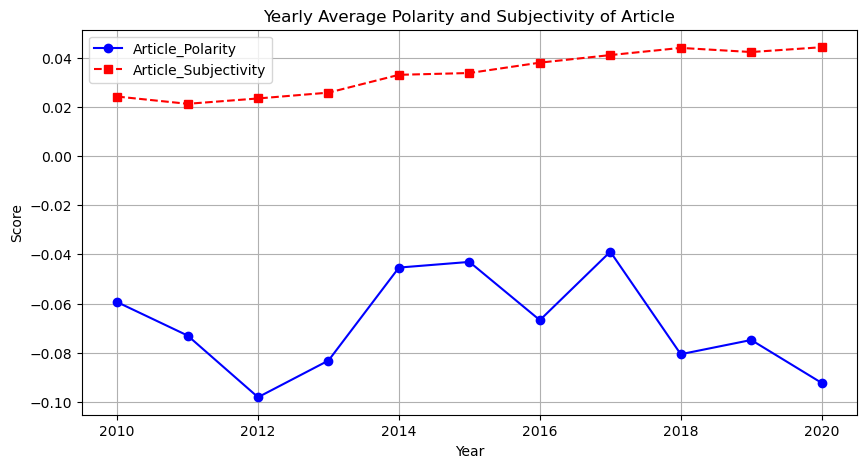

In [20]:
# 画图
plt.figure(figsize=(10, 5))
plt.plot(yearly_stats['Year'], yearly_stats['Article_Polarity'], marker='o', linestyle='-', label='Article_Polarity', color='b')
plt.plot(yearly_stats['Year'], yearly_stats['Article_Subjectivity'], marker='s', linestyle='--', label='Article_Subjectivity', color='r')

plt.xlabel('Year')
plt.ylabel('Score')
plt.title('Diachronic Average Polarity and Subjectivity of Article')
plt.legend()
plt.grid()
plt.show()

In [7]:
#基于Harvard General Inquirer Dictionary词典的情感分析

In [16]:
dictionary2= pd.read_excel("C:/Users/WQM/Desktop/本科英语毕业论文/数据集/FNSPID/Dictionary/inquirerbasic.xls")
dictionary2= pd.DataFrame(dictionary2)

In [17]:
dictionary2_sim= dictionary2.loc[:,['Entry', 'Positiv', 'Negativ']]

In [18]:
# 初始化类别词典
word_dict2 = {
    'positive': [],
    'negative': [],
}

In [19]:
# 遍历DataFrame，分类存入字典
for _, row in dictionary2_sim.iterrows():
    if row['Positiv'] == "Positiv":
        word_dict2['positive'].append(row['Entry'])
    if row['Negativ'] == "Negativ":
        word_dict2['negative'].append(row['Entry'])

In [20]:
# 处理字典中的每个值
for key in word_dict2:
    word_dict2[key] = [re.sub(r'[\d#]+$', '', str(word)).lower() for word in word_dict2[key]]

In [21]:
for key in word_dict2:
    word_dict2[key] = list(dict.fromkeys(word_dict2[key]))

In [22]:
# 计算词频
def count_words(text, word_list):
    return sum(text.lower().split().count(word) for word in word_list)

In [23]:
data['GI_Title_Positive'] = data['Article_title'].apply(lambda x: count_words(x, word_dict2['positive']))
data['GI_Title_Negative'] = data['Article_title'].apply(lambda x: count_words(x, word_dict2['negative']))
data['Title_Total_Words'] = data['Article_title'].apply(lambda x: len(x.split()))  # 计算文章词数

# 计算情感极性和主观性
data['GI_Title_Polarity'] = (data['GI_Title_Positive'] - data['GI_Title_Negative']) / (data['GI_Title_Positive'] + data['GI_Title_Negative']).replace(0, 1)  # 避免除0
data['GI_Title_Subjectivity'] = (data['GI_Title_Positive'] + data['GI_Title_Negative']) / data['Title_Total_Words']

In [39]:
# 按年计算平均值
yearly_stats = data.groupby('Year')[['GI_Title_Polarity', 'GI_Title_Subjectivity']].mean().reset_index()

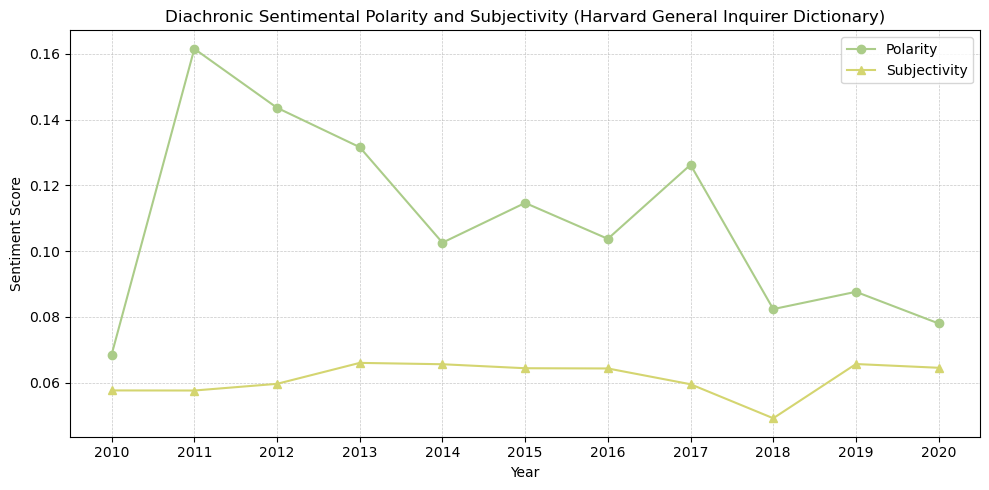

In [40]:
# 画图
plt.figure(figsize=(10, 5))
plt.plot(yearly_stats['Year'], yearly_stats['GI_Title_Polarity'], marker='o', linestyle='-', label='Polarity', color='#ABCC89')
plt.plot(yearly_stats['Year'], yearly_stats['GI_Title_Subjectivity'], marker='^', linestyle='-', label='Subjectivity', color='#D4D570')

# 设置 x 轴刻度，确保每个年份都显示
plt.xticks(yearly_stats['Year'])

# 细虚线网格
plt.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

plt.xlabel('Year')
plt.ylabel('Sentiment Score')
plt.title('Diachronic Sentimental Polarity and Subjectivity (Harvard General Inquirer Dictionary)')
plt.legend()

plt.tight_layout()

# 保存图像
plt.savefig("Diachronic Sentimental Polarity and Subjectivity (Harvard General Inquirer Dictionary).jpg", format="jpg", dpi=300)
plt.show()

In [54]:
# 计算词频
def count_words(text, word_list):
    return sum(text.lower().split().count(word) for word in word_list)

In [ ]:
# 使用 tqdm 包装 DataFrame 的 apply 方法
tqdm.pandas()

# 计算正面词汇数
data['GI_Article_Positive'] = data['Article'].progress_apply(lambda x: count_words(x, word_dict2['positive']))

# 计算负面词汇数
data['GI_Article_Negative'] = data['Article'].progress_apply(lambda x: count_words(x, word_dict2['negative']))

# 计算情感极性
data['GI_Article_Polarity'] = (data['GI_Article_Positive'] - data['GI_Article_Negative']) / (data['GI_Article_Positive'] + data['GI_Article_Negative']).replace(0, 1)  # 避免除0

# 按年计算平均值
yearly_stats = data.groupby('Year')[['GI_Article_Polarity']].mean().reset_index()

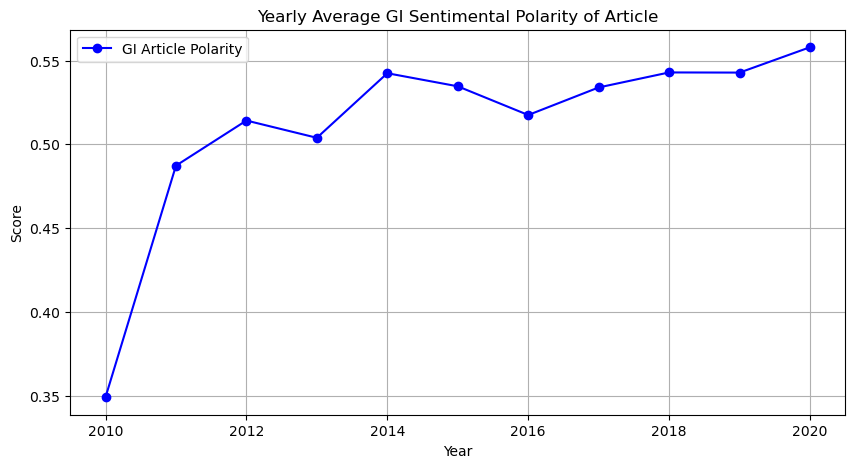

In [60]:
# 画图
plt.figure(figsize=(10, 5))
plt.plot(yearly_stats['Year'], yearly_stats['GI_Article_Polarity'], marker='o', linestyle='-', label='GI Article Polarity', color='b')

plt.xlabel('Year')
plt.ylabel('Score')
plt.title('Diachronic Average GI Sentimental Polarity of Article')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# LM词典和GI词典比较

In [92]:
# 先转换为集合
word_dict_pos_set = set(word_dict["positive"])
word_dict_neg_set = set(word_dict["negative"])
word_dict2_pos_set = set(word_dict2["positive"])
word_dict2_neg_set = set(word_dict2["negative"])

# 计算独有词汇和交叉词汇
word_dict_positive_unique = word_dict_pos_set - word_dict2_pos_set
word_dict_negative_unique = word_dict_neg_set - word_dict2_neg_set

word_dict2_positive_unique = word_dict2_pos_set - word_dict_pos_set
word_dict2_negative_unique = word_dict2_neg_set - word_dict_neg_set

In [93]:
pos_in_dict1_neg_in_dict2 = word_dict_pos_set & word_dict2_neg_set
pos_in_dict2_neg_in_dict1 = word_dict2_pos_set & word_dict_neg_set

In [94]:
pos_in_dict1_neg_in_dict2

{'incredible'}

In [95]:
pos_in_dict2_neg_in_dict1

{'acquit',
 'acquittal',
 'arrest',
 'condone',
 'conviction',
 'correction',
 'defend',
 'imperative',
 'overcome',
 'prosecute',
 'reparation',
 'serious',
 'seriousness',
 'tolerate',
 'toleration'}

In [ ]:
# 美国经济数据

In [6]:
data_eco= pd.read_excel("C:/Users/WQM/Desktop/本科英语毕业论文/数据集/FNSPID/美国宏观数据/RGDP.xlsx")
data_eco= pd.DataFrame(data_eco)

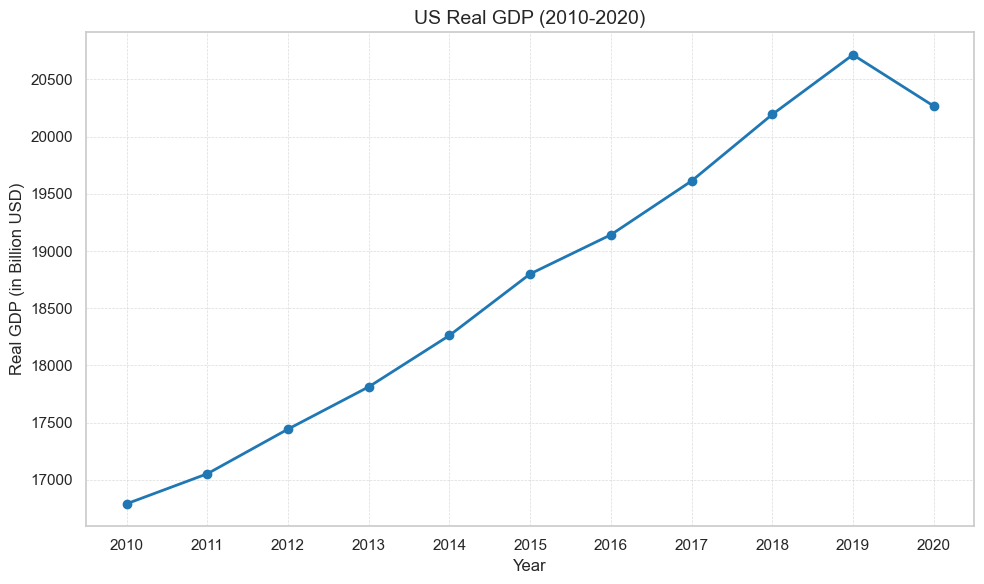

In [102]:
# 绘制折线图
plt.figure(figsize=(10, 6))
plt.plot(data_eco["Year"], data_eco["RGDP"], marker="o", linestyle="-", color="#1f77b4", linewidth=2)

# 设置标题和轴标签
plt.title("US Real GDP (2010-2020)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Real GDP (in Billion USD)", fontsize=12)

# 显示网格
plt.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# 设置 x 轴刻度
plt.xticks(data_eco["Year"])

# 调整布局
plt.tight_layout()

# 显示图像
plt.show()

In [105]:
data_eco2= pd.read_excel("C:/Users/WQM/Desktop/本科英语毕业论文/数据集/FNSPID/美国宏观数据/RGPDI.xlsx")
data_eco2= pd.DataFrame(data_eco2)

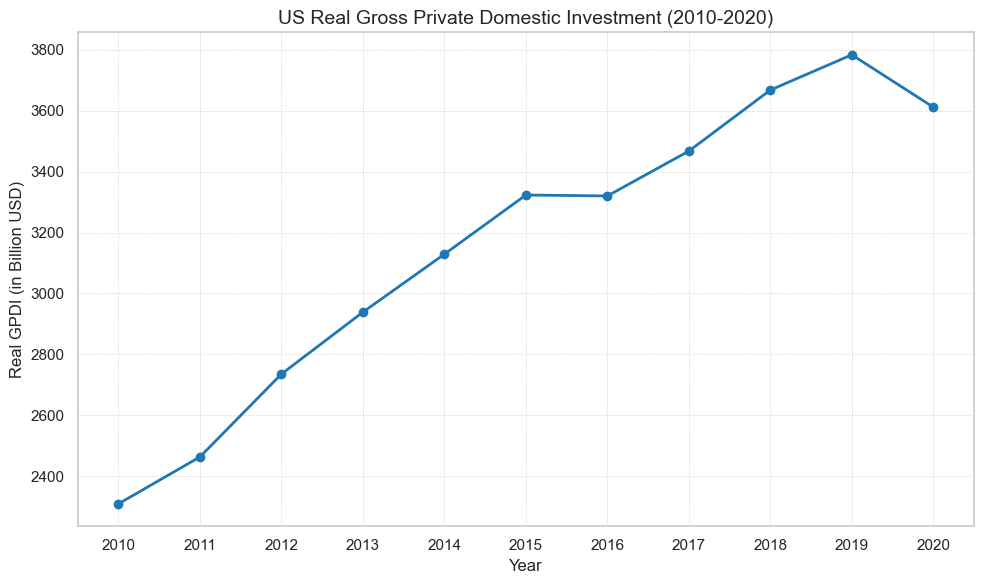

In [121]:
# 绘制折线图
plt.figure(figsize=(10, 6))
plt.plot(data_eco2["Year"], data_eco2["RGPDI"], marker="o", linestyle="-", color="#1f77b4", linewidth=2)

# 设置标题和轴标签
plt.title("US Real Gross Private Domestic Investment (2010-2020)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Real GPDI (in Billion USD)", fontsize=12)

# 显示网格
plt.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# 设置 x 轴刻度
plt.xticks(data_eco2["Year"])

# 调整布局
plt.tight_layout()

plt.savefig("US Real Gross Private Domestic Investment (2010-2020).jpg", format="jpg", dpi=300)

# 显示图像
plt.show()

In [7]:
data_eco3= pd.read_excel("C:/Users/WQM/Desktop/本科英语毕业论文/数据集/FNSPID/美国宏观数据/GR_RGDP.xlsx")
data_eco3= pd.DataFrame(data_eco3)

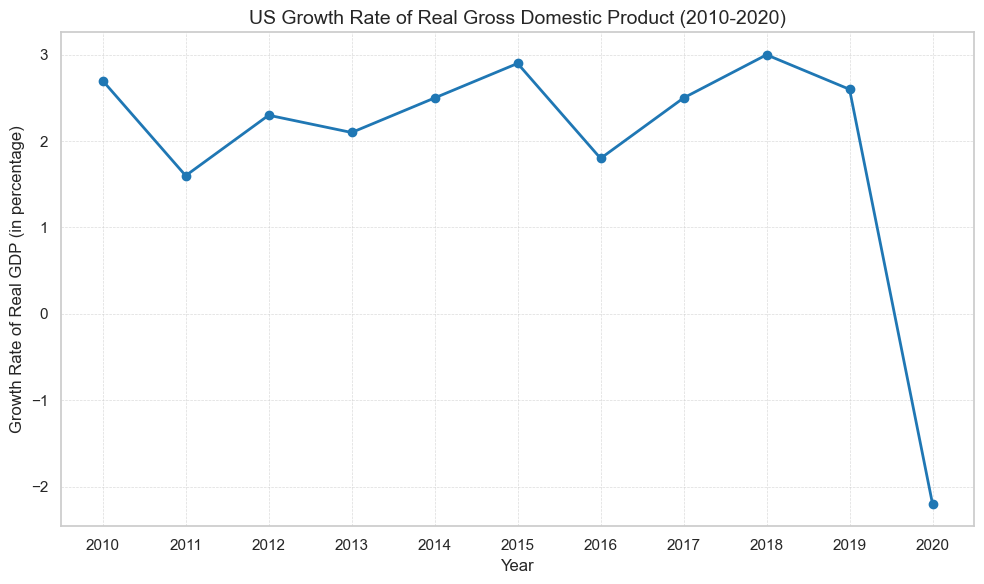

In [122]:
# 绘制折线图
plt.figure(figsize=(10, 6))
plt.plot(data_eco3["Year"], data_eco3["GR_RGDP"], marker="o", linestyle="-", color="#1f77b4", linewidth=2)

# 设置标题和轴标签
plt.title("US Growth Rate of Real Gross Domestic Product (2010-2020)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Growth Rate of Real GDP (in percentage)", fontsize=12)

# 显示网格
plt.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# 设置 x 轴刻度
plt.xticks(data_eco3["Year"])

# 调整布局
plt.tight_layout()

plt.savefig("US Growth Rate of Real Gross Domestic Product (2010-2020).jpg", format="jpg", dpi=300)

# 显示图像
plt.show()

In [8]:
data_merge= pd.merge(data_eco, data_eco3, on=['Year'])

In [9]:
data_merge

,Year,RGDP,GR_RGDP
0,2010,16789.750,2.7
1,2011,17052.410,1.6
2,2012,17442.759,2.3
3,2013,17812.167,2.1
4,2014,18261.714,2.5
5,2015,18799.622,2.9
6,2016,19141.672,1.8
7,2017,19612.102,2.5
8,2018,20193.896,3.0
9,2019,20715.671,2.6


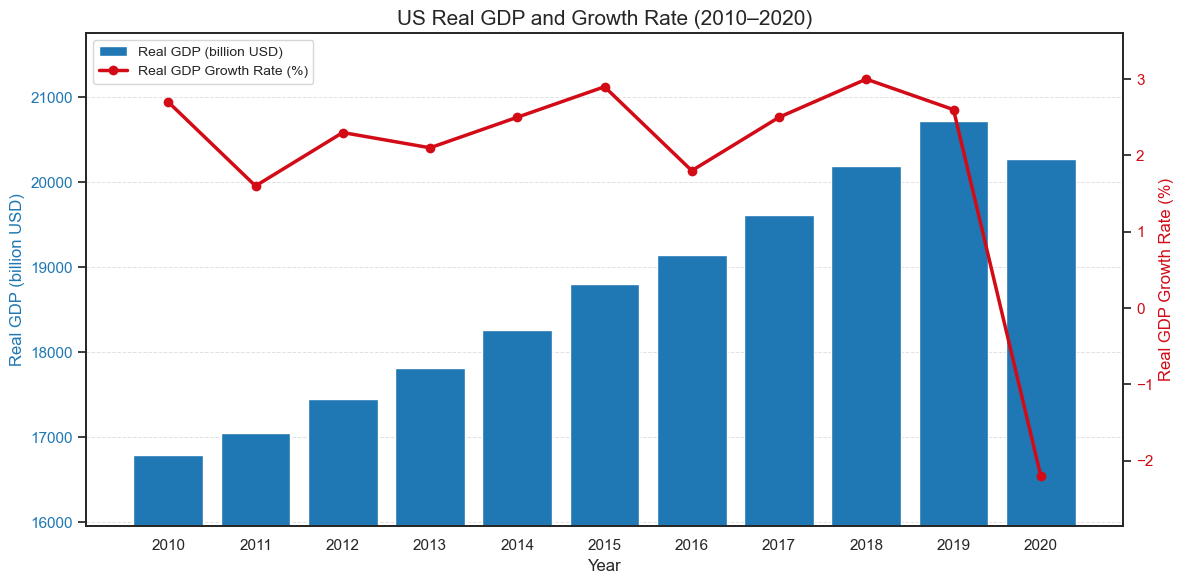

In [24]:
# 清爽白色风格
sns.set(style="white")

fig, ax1 = plt.subplots(figsize=(12, 6))

# 柱状图：RGDP
bar = ax1.bar(data_merge["Year"], data_merge["RGDP"],
              color="#1f77b4", label="Real GDP (billion USD)")

# 主坐标轴设置（GDP）
ax1.set_ylabel("Real GDP (billion USD)", fontsize=12, color="#1f77b4")
ax1.set_xlabel("Year", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_xticks(data_merge["Year"])
ax1.set_xticklabels(data_merge["Year"])

# GDP 不从0开始
gdp_min = data_merge["RGDP"].min()
gdp_max = data_merge["RGDP"].max()
ax1.set_ylim(gdp_min * 0.95, gdp_max * 1.05)

# 添加统一背景网格线（虚线）
ax1.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)

# 折线图：GDP增长率
ax2 = ax1.twinx()
line = ax2.plot(data_merge["Year"], data_merge["GR_RGDP"],
                color="#d20b17", marker='o', linewidth=2.5,
                label="Real GDP Growth Rate (%)")
ax2.set_ylabel("Real GDP Growth Rate (%)", fontsize=12, color="#d20b17")
ax2.tick_params(axis="y", labelcolor="#d20b17")

# 设置右侧轴范围
growth_min = data_merge["GR_RGDP"].min()
growth_max = data_merge["GR_RGDP"].max()
ax2.set_ylim(growth_min * 1.3, growth_max * 1.2)

# 图例
lines_labels = [bar, line[0]]
labels = [l.get_label() for l in lines_labels]
ax1.legend(lines_labels, labels, loc="upper left", fontsize=10)

# 标题
plt.title("US Real GDP and Growth Rate (2010–2020)", fontsize=15)

plt.tight_layout()

plt.savefig("US Real GDP and Growth Rate (2010–2020).jpg", format="jpg", dpi=300)

plt.show()

In [101]:
data_eco

,Year,RGDP
0,2010,16789.750
1,2011,17052.410
2,2012,17442.759
3,2013,17812.167
4,2014,18261.714
5,2015,18799.622
6,2016,19141.672
7,2017,19612.102
8,2018,20193.896
9,2019,20715.671


In [36]:
data

,Date,Stock_symbol,Article_title,Article,Url,Publisher,Year,FB_title_polarity,FB_title_label,GI_Title_Positive,GI_Title_Negative,Title_Total_Words,GI_Title_Polarity,GI_Title_Subjectivity,LM_Title_Positive,LM_Title_Negative,LM_Title_Polarity,LM_Title_Subjectivity
0,2010-1-1,DRR,sizemore capital 2009 year end investment outl...,as we enter 2010 let us take a moment to refle...,https://www.benzinga.com/74341/sizemore-capita...,Charles Lewis Sizemore CFA,2010,1,positive,0,1,9,-1.0,0.111111,0,0,0.0,0.000000
1,2010-1-10,PRXI,investment analysis premier exhibitions prxi a...,note for those not familiar with premier and i...,https://www.benzinga.com/100145/investment-ana...,Above Average Odds,2010,-1,negative,2,0,14,1.0,0.142857,2,0,1.0,0.142857
2,2010-1-11,AA,stock market news for january 11 2010 market news,a surprise drop in december nonfarm payrolls h...,https://www.benzinga.com/82688/stock-market-ne...,Zacks,2010,1,positive,0,0,9,0.0,0.000000,0,0,0.0,0.000000
3,2010-1-11,AA,stock watch list for january 11 2010,happy monday to you all we have positive bias ...,https://www.benzinga.com/82225/stock-watch-lis...,Ryan Mallory,2010,1,positive,0,0,7,0.0,0.000000,0,0,0.0,0.000000
4,2010-1-11,AA,benzinga ’s top pre market gainers ddss immu v...,labopharm inc. nasdaq ddss increased 4.44 to 2...,https://www.benzinga.com/pre-market-outlook/82...,BenzingaStaff3,2010,1,positive,0,0,13,0.0,0.000000,0,0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24149,2020-6-9,NMIH,nmi holdings shares are trading lower after ke...,never miss a trade again with the fastest news...,https://www.benzinga.com/wiim/20/06/16212763/n...,Benzinga Newsdesk,2020,0,neutral,1,1,26,0.0,0.076923,1,1,0.0,0.076923
24150,2020-6-9,NNVC,nanoviricides signs memorandum of understandin...,never miss a trade again with the fastest news...,https://www.benzinga.com/general/biotech/20/06...,Benzinga Newsdesk,2020,-1,negative,1,0,11,1.0,0.090909,0,0,0.0,0.000000
24151,2020-6-9,SIVR,gold is n't the only reason this miners etf is...,some commodities are getting absolutely wrecke...,https://www.benzinga.com/trading-ideas/long-id...,ETF Professor,2020,1,positive,1,0,11,1.0,0.090909,0,0,0.0,0.000000
24152,2020-6-9,VRML,vermillion set to join russell 3000 index,never miss a trade again with the fastest news...,https://www.benzinga.com/news/20/06/16216740/v...,Benzinga Newsdesk,2020,1,positive,1,0,7,1.0,0.142857,0,0,0.0,0.000000


In [37]:
data.to_excel("2010-2020 FNSPID Corpus Sentiment Analysis.xlsx", index=False)